In [1]:
import os
import sys

import json
import random
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path
from IPython.display import clear_output
from collections import Counter

In [2]:
MODULES_PATH = Path("../modules").resolve()

if str(MODULES_PATH) not in sys.path:
    sys.path.insert(0, str(MODULES_PATH))

from corpus import get_gt_dict
from data_config import DATA_CONFIG
from plotting import format_axes
from error_analysis import ERROR_CATEGORIES

import api

In [3]:
EPI_NUM = "008"
CALL_API = True
DATASET_SPLIT = "test"

DATASET_PATH = DATA_CONFIG[DATASET_SPLIT]["paths"]["epi_dir"]

random.seed(42)
SAVE_PATH = f"../../data/results/error_codes"

In [4]:
# ---------- Load EPI log ----------
with open(f"{DATASET_PATH}/epi_{EPI_NUM}.json") as f:
    epi_log = json.load(f)

FileNotFoundError: [Errno 2] No such file or directory: '../../data/results/epis/biored_test/epi_008.json'

In [ ]:
# ---------- Sample FP/FN errors ----------
error_samples = {}

SAMPLE_SIZE = 50

for i in ("relations", "entities"):

    fp = epi_log["errors"]["errors"][i]["false_positives"]
    fn = epi_log["errors"]["errors"][i]["false_negatives"]

    error_samples[i] = {
        "fp": random.Random(42).sample(fp, SAMPLE_SIZE) if len(fp) > SAMPLE_SIZE else fp,
        "fn": random.Random(42).sample(fn, SAMPLE_SIZE) if len(fn) > SAMPLE_SIZE else fn,
    }

    print(f"'{i}' FP Sample Length: {len(error_samples[i]["fp"])}")
    print(f"'{i}' FN Sample Length: {len(error_samples[i]["fn"])}")
    print("")

'relations' FP Sample Length: 50
'relations' FN Sample Length: 50

'entities' FP Sample Length: 50
'entities' FN Sample Length: 50



In [ ]:
# ---------- Import GTs ----------
gt = pd.read_csv(DATA_CONFIG[DATASET_SPLIT]["paths"]["ground_truths"])
entities_gt = pd.read_csv(DATA_CONFIG[DATASET_SPLIT]["paths"]["entities_ground_truths"])
gt_dict = get_gt_dict(gt, entities_gt)

In [ ]:
# ---------- Import BioRED train abstracts ----------
abstracts = pd.read_csv(DATA_CONFIG[DATASET_SPLIT]["paths"]["abstracts"])

In [ ]:
# ---------- Save FP/FN errors to JSON ----------
ERROR_SAMPLE_DIR = f"../../data/error_sampling"

os.makedirs(ERROR_SAMPLE_DIR, exist_ok=True)
with open(os.path.join(ERROR_SAMPLE_DIR, f"epi_{EPI_NUM}_error_samples.json"), "w") as f:
    json.dump(error_samples, f, indent=2, default=list)

In [ ]:
# ---------- LLM call ----------
if CALL_API:
    # ---------- Relations (LLM-categorised) ----------

    client = api.create_client()

    print("Client created...")
    print("Evaluating errors against error types...")

    clear_output(wait=True)

    error_codes = []

    category_list_str = "\n".join(f"{k}: {v}" for k, v in ERROR_CATEGORIES.items())

    for error_type, errors in error_samples["relations"].items():
        for error in errors:

            pmid = error[0]

            matching_gts = [
                gt for gt in gt_dict["relations"]
                if gt[0] == pmid
            ]

            category_list_str = "\n".join(
                f"{num}. {cat['name']}: {cat['description']}"
                for num, cat in ERROR_CATEGORIES.items()
            )

            prompt = f"""You are reviewing a relation-extraction error made by an NLP system.\n\nError type: {error_type}\n- fp: a predicted relation that did not match the BioRED ground truth under the evaluation procedure.\n- fn: a BioRED ground-truth relation that was not matched by a prediction.\n\nRelation being analysed:\n{error}\n\nAbstract:{abstracts.set_index("pmid").loc[pmid]}\n\nGround-truth relations for this abstract:\n{chr(10).join(str(gt) for gt in matching_gts)}\n\nCategorise the primary cause of this error into exactly one of the categories below. Each category has a name and a description explaining when it applies — use the descriptions to guide your decision.\n\n{category_list_str}\n\nUse the abstract and BioRED ground truth as the reference when making your decision.\nIf multiple categories could apply, select the category that best explains why the prediction and ground truth did not match.\n\nRespond with ONLY the category number, nothing else."""

            response = client.responses.create(
                model="gpt-5.6-luna",
                input=prompt
            )

            error_code = response.output_text.strip()

            error_codes.append({
                "error_type": str(error_type),
                "error": error,
                "category": ERROR_CATEGORIES.get(error_code, "Invalid")
            })

            with open(f"{SAVE_PATH}/epi_{EPI_NUM}.json", "w") as f:
                json.dump(error_codes, f, indent=4)

    print(f"Saved `error_codes` for epi_{EPI_NUM} to `{SAVE_PATH}/epi_{EPI_NUM}.json` successfully.")

else:
    with open(f"{SAVE_PATH}/epi_{EPI_NUM}.json", "r") as f:
        error_codes = json.load(f)

    print(f"Loaded `error_codes` for epi_{EPI_NUM} from `{SAVE_PATH}/epi_{EPI_NUM}.json` successfully.")

Saved `error_codes` for epi_008 to `../../data/results/error_codes/epi_008.json` successfully.


In [ ]:
# ---------- Extract FP/FN separately ----------
fp_counts = pd.Series(
    Counter(error["category"]["name"] for error in error_codes if error["error_type"] == "fp")
)

fn_counts = pd.Series(
    Counter(error["category"]["name"] for error in error_codes if error["error_type"] == "fn")
)

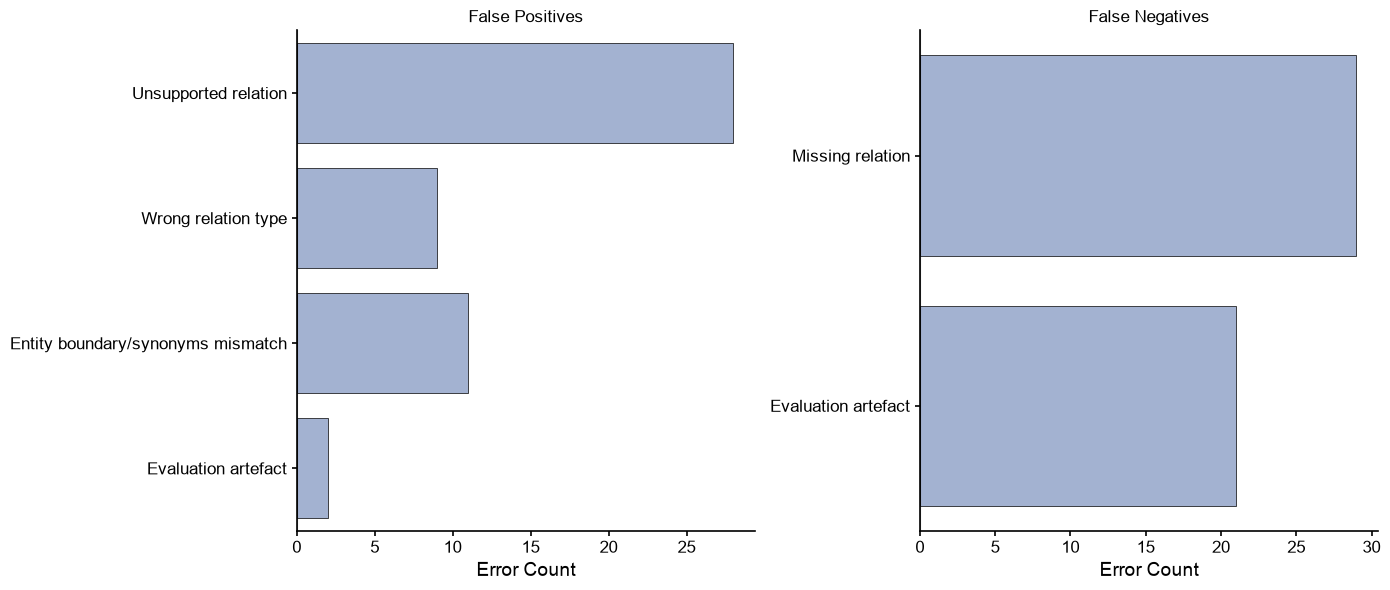

In [ ]:
# ---------- Plot FP/FN categories fig ----------
plt.rcParams['font.family'] = 'arial'

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.barplot(
    x=fp_counts.values,
    y=fp_counts.index,
    ax=axes[0],
    color="#9bafd9",
    edgecolor="black",
    linewidth=0.5
)
format_axes(axes[0], "Error")
axes[0].set_title("False Positives")

sns.barplot(
    x=fn_counts.values,
    y=fn_counts.index,
    ax=axes[1],
    color="#9bafd9",
    edgecolor="black",
    linewidth=0.5
)
format_axes(axes[1], "Error")
axes[1].set_title("False Negatives")

plt.tight_layout()

In [ ]:
fig.savefig(f"../../img/error_analysis/{DATA_CONFIG[DATASET_SPLIT]["name"]}/epi_{EPI_NUM}.png", dpi=150)